In [2]:
res_path = "/home/ts/tcs/pr/eos/results/"
import torch
import matplotlib.pyplot as plt
from os import environ
import NGD
from utilities import make_base_directory

In [3]:
def make_directory(dataset, arch_id, loss, params, seed=0, ngd_type="ngd"):
    base_dir = make_base_directory(dataset, arch_id, loss)
    directory = f"{base_dir}/seed_{seed}/{ngd_type}/{params.get_dirname()}"
    return directory

In [4]:
import torch
import matplotlib.pyplot as plt
import numpy as np

def interpolate_color(factor):
    c1 = torch.tensor([1.0, 0.0, 0.0])
    c2 = torch.tensor([0.0, 1.0, 1.0])
    color = (1 - factor) * c1 + factor * c2
    return tuple(color.tolist())

def smooth_tensor(tensor, smoothing=0.9):
    """Exponential Moving Average (EMA) smoothing."""
    if tensor is None: return None
    smoothed = [tensor[0]]
    for i in range(1, len(tensor)):
        smoothed.append(smoothing * smoothed[-1] + (1 - smoothing) * tensor[i])
    return torch.tensor(smoothed)

def plot_multiple_experiments(experiments, show_interval=None, smoothing=0.9):
    print(f"Plotting {len(experiments)} experiments")

    color_values = [e[3] for e in experiments if e[3] is not None]
    min_color, max_color = (min(color_values), max(color_values)) if color_values else (0, 1)

    all_cos_similarity, all_test_loss, all_test_acc = [], [], []
    all_train_loss, all_train_acc = [], []
    all_ng_norm, all_grad_norm, all_sharpness = [], [], []
    all_fim_diag_norm, labels, gd_freqs, colors = [], [], [], []

    for directory, label, gd_eig_freq, color_value in experiments:
        print(f"Loading from {directory}")

        test_loss = torch.load(f"{directory}/test_loss")
        test_acc = torch.load(f"{directory}/test_acc")
        train_loss = torch.load(f"{directory}/train_loss")
        train_acc = torch.load(f"{directory}/train_acc")
        sharpness = torch.load(f"{directory}/eigs")[:, 0]

        try:
            cos_similarity = torch.load(f"{directory}/cos_similarity")
            ng_norm = torch.load(f"{directory}/ng_norm")
            grad_norm = torch.load(f"{directory}/grad_norm")
            fim_diag_norm = torch.load(f"{directory}/FIM_diag_norm")
        except FileNotFoundError as e:
            cos_similarity = ng_norm = grad_norm = fim_diag_norm = None
            print(f"Warning: {e}. Some metrics may not be available.")

        if show_interval is not None:
            begin, end = show_interval
            test_loss = test_loss[begin:end]
            test_acc = test_acc[begin:end]
            train_loss = train_loss[begin:end]
            train_acc = train_acc[begin:end]
            sharpness = sharpness[begin:end]
            cos_similarity = cos_similarity[begin:end] if cos_similarity is not None else None
            ng_norm = ng_norm[begin:end] if ng_norm is not None else None
            grad_norm = grad_norm[begin:end] if grad_norm is not None else None
            fim_diag_norm = fim_diag_norm[begin:end] if fim_diag_norm is not None else None

        # Apply smoothing only
        all_cos_similarity.append(smooth_tensor(cos_similarity, smoothing) if cos_similarity is not None else None)
        all_test_loss.append(smooth_tensor(test_loss, smoothing))
        all_test_acc.append(smooth_tensor(test_acc, smoothing))
        all_train_loss.append(smooth_tensor(train_loss, smoothing))
        all_train_acc.append(smooth_tensor(train_acc, smoothing))
        all_ng_norm.append(smooth_tensor(ng_norm, smoothing) if ng_norm is not None else None)
        all_grad_norm.append(smooth_tensor(grad_norm, smoothing) if grad_norm is not None else None)
        all_sharpness.append(smooth_tensor(sharpness, smoothing))
        all_fim_diag_norm.append(smooth_tensor(fim_diag_norm, smoothing) if fim_diag_norm is not None else None)

        labels.append(label)
        gd_freqs.append(gd_eig_freq)

        if color_value is None:
            colors.append(None)
        else:
            f = (color_value - min_color) / (max_color - min_color) if max_color != min_color else 0.5
            colors.append(interpolate_color(f))

    fig, axs = plt.subplots(4, 2, figsize=(12, 12), dpi=100)
    axs = axs.flatten()

    metrics = [
        ("Test Loss", all_test_loss, axs[0], False),
        ("Test Accuracy", all_test_acc, axs[1], False),
        ("Train Loss", all_train_loss, axs[2], False),
        ("FIM diag norm", all_fim_diag_norm, axs[3], False),
        ("NG Norm (log scale)", all_ng_norm, axs[4], True),
        ("Grad Norm", all_grad_norm, axs[5], False),
        ("Cosine Similarity", all_cos_similarity, axs[6], False),
        ("Sharpness (Top Eigenvalue)", all_sharpness, axs[7], False),
    ]

    for title, data_list, ax, log_scale in metrics:
        for i, y in enumerate(data_list):
            if y is None: continue
            x = torch.arange(len(y)) * gd_freqs[i] if "Sharpness" in title else torch.arange(len(y))
            color = colors[i]
            if log_scale:
                ax.semilogy(x, y, label=labels[i], color=color, linewidth=1.5)
            else:
                ax.plot(x, y, label=labels[i], color=color, linewidth=1.5)
        ax.set_title(title)
        ax.set_xlabel("Iteration")
        ax.grid(True, linestyle='--', linewidth=0.5)
        ax.legend(fontsize=7, loc='best')

    plt.tight_layout()
    plt.show()


Plotting 4 experiments
Loading from /home/ts/tcs/pr/eos/edge-of-stability/results/cifar10/fc-tanh/mse/seed_0/ngd/lr_0.0001__fisher_bs_1000__phys_bs_1000__epsilon_1e-06
Loading from /home/ts/tcs/pr/eos/edge-of-stability/results/cifar10/fc-tanh/mse/seed_0/ngd/lr_0.001__fisher_bs_1000__phys_bs_1000__epsilon_1e-06
Loading from /home/ts/tcs/pr/eos/edge-of-stability/results/cifar10/fc-tanh/mse/seed_1/ngd/lr_0.01__fisher_bs_1000__phys_bs_1000__epsilon_1e-06
Loading from /home/ts/tcs/pr/eos/edge-of-stability/results/cifar10/fc-tanh/mse/seed_1/ngd/lr_0.1__fisher_bs_1000__phys_bs_1000__epsilon_1e-06


/tmp/ipykernel_6167/1028652032.py:106: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=7, loc='best')


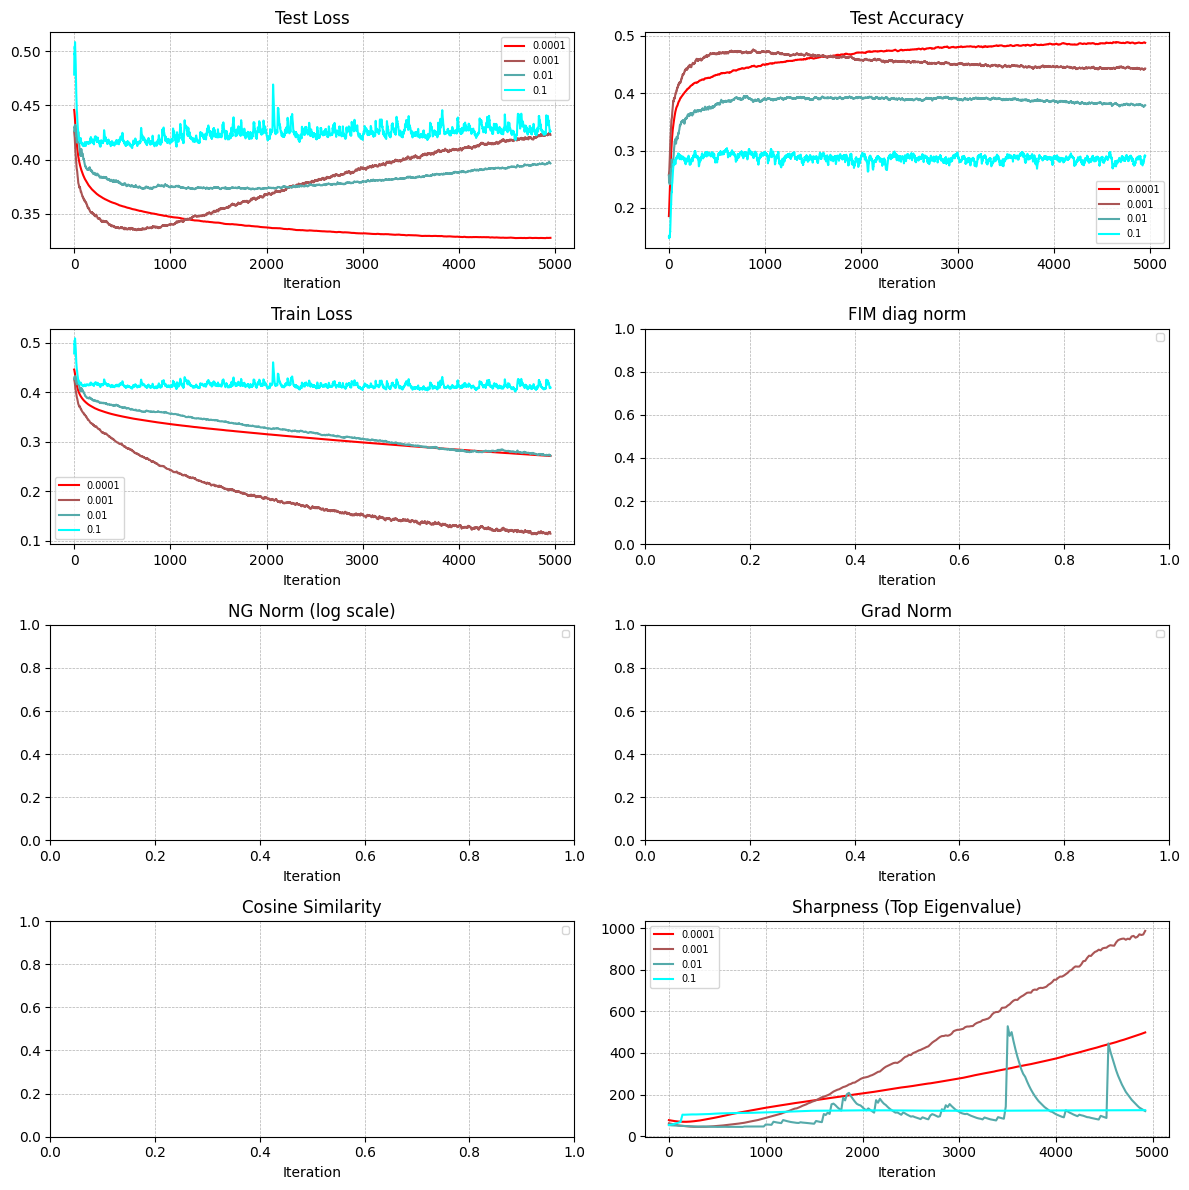

In [5]:
dataset = "cifar10"
arch_id = "fc-tanh"
loss = "mse"

plot_multiple_experiments([
    (make_directory(dataset, arch_id, loss, NGD.EmpiricalNGD.Params(
        lr = 0.0001,
        fisher_batch_size=1000,
        physical_batch_size=1000,
        epsilon=1e-6,
        ), seed=0), 
        "0.0001", 20, 0),
    (make_directory(dataset, arch_id, loss, NGD.EmpiricalNGD.Params(
        lr = 0.001,
        fisher_batch_size=1000,
        physical_batch_size=1000,
        epsilon=1e-6,
        ), seed=0), 
        "0.001", 20, 1),
    (make_directory(dataset, arch_id, loss, NGD.EmpiricalNGD.Params(
        lr = 0.01,
        fisher_batch_size=1000,
        physical_batch_size=1000,
        epsilon=1e-6,
        ), seed=1), 
        "0.01", 20, 2),
    (make_directory(dataset, arch_id, loss, NGD.EmpiricalNGD.Params(
        lr = 0.1,
        fisher_batch_size=1000,
        physical_batch_size=1000,
        epsilon=1e-6,
        ), seed=1),
        "0.1", 20, 3),
    ], [0, 5000])

Plotting 4 experiments
Loading from /home/ts/tcs/pr/eos/edge-of-stability/results/cifar10/fc-tanh/mse/seed_1/ngd/lr_0.0001__fisher_bs_10000__phys_bs_1000__epsilon_1e-06


Loading from /home/ts/tcs/pr/eos/edge-of-stability/results/cifar10/fc-tanh/mse/seed_1/ngd/lr_0.001__fisher_bs_10000__phys_bs_1000__epsilon_1e-06
Loading from /home/ts/tcs/pr/eos/edge-of-stability/results/cifar10/fc-tanh/mse/seed_1/ngd/lr_0.01__fisher_bs_10000__phys_bs_1000__epsilon_1e-06
Loading from /home/ts/tcs/pr/eos/edge-of-stability/results/cifar10/fc-tanh/mse/seed_1/ngd/lr_0.1__fisher_bs_10000__phys_bs_1000__epsilon_1e-06


/tmp/ipykernel_6167/1028652032.py:106: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=7, loc='best')


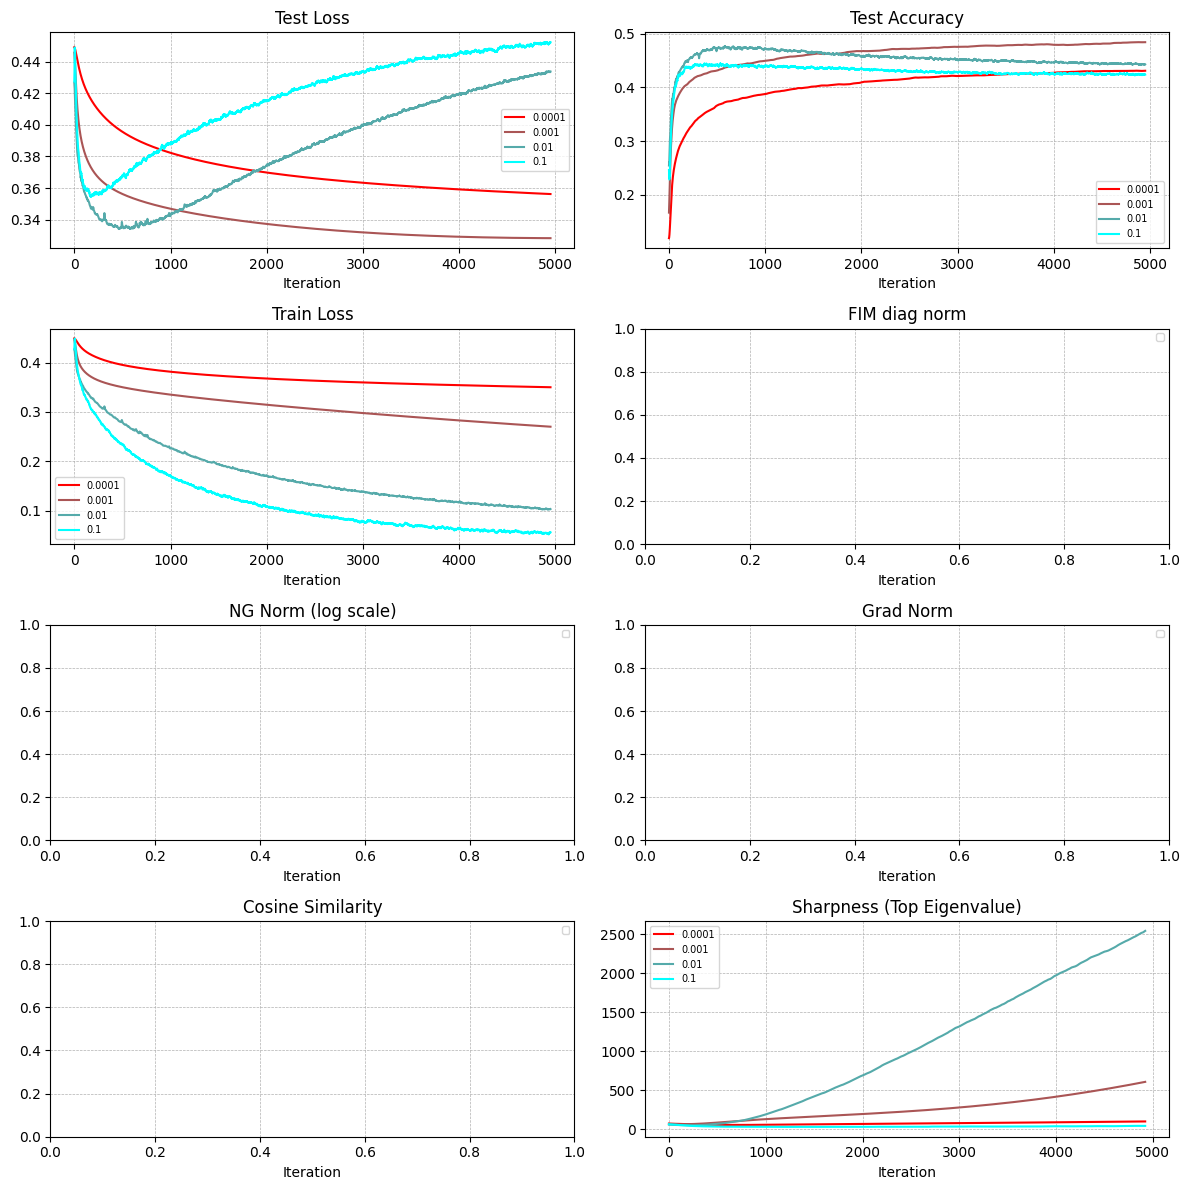

In [6]:
dataset = "cifar10"
arch_id = "fc-tanh"
loss = "mse"

plot_multiple_experiments([
    (make_directory(dataset, arch_id, loss, NGD.EmpiricalNGD.Params(
        lr = 0.0001,
        fisher_batch_size=10000,
        physical_batch_size=1000,
        epsilon=1e-6,
        ), seed=1), 
        "0.0001", 20, 0),
    (make_directory(dataset, arch_id, loss, NGD.EmpiricalNGD.Params(
        lr = 0.001,
        fisher_batch_size=10000,
        physical_batch_size=1000,
        epsilon=1e-6,
        ), seed=1), 
        "0.001", 20, 1),
    (make_directory(dataset, arch_id, loss, NGD.EmpiricalNGD.Params(
        lr = 0.01,
        fisher_batch_size=10000,
        physical_batch_size=1000,
        epsilon=1e-6,
        ), seed=1), 
        "0.01", 20, 2),
    (make_directory(dataset, arch_id, loss, NGD.EmpiricalNGD.Params(
        lr = 0.1,
        fisher_batch_size=10000,
        physical_batch_size=1000,
        epsilon=1e-6,
        ), seed=1), 
        "0.1", 20, 3),
    
    ])

w kolorowych wynikach Fisher nie był normalizowany!

Plotting 4 experiments
Loading from /home/ts/tcs/pr/eos/edge-of-stability/results/cifar10/cnn-relu/ce/seed_0/ngd/lr_1e-05__fisher_bs_50000__phys_bs_5000__epsilon_1e-05
Loading from /home/ts/tcs/pr/eos/edge-of-stability/results/cifar10/cnn-relu/ce/seed_0/ngd/lr_1.0__fisher_bs_50000__phys_bs_5000__epsilon_1e-05__clip_0.1
Loading from /home/ts/tcs/pr/eos/edge-of-stability/results/cifar10/cnn-relu/ce/seed_0/ngd/lr_0.0005__fisher_bs_50000__phys_bs_5000__epsilon_1e-05__gd_only_True
Loading from /home/ts/tcs/pr/eos/edge-of-stability/results/cifar10/cnn-relu/ce/seed_0/ngd/lr_0.0001__fisher_bs_50000__phys_bs_5000__epsilon_1e-05__momentum_0.9


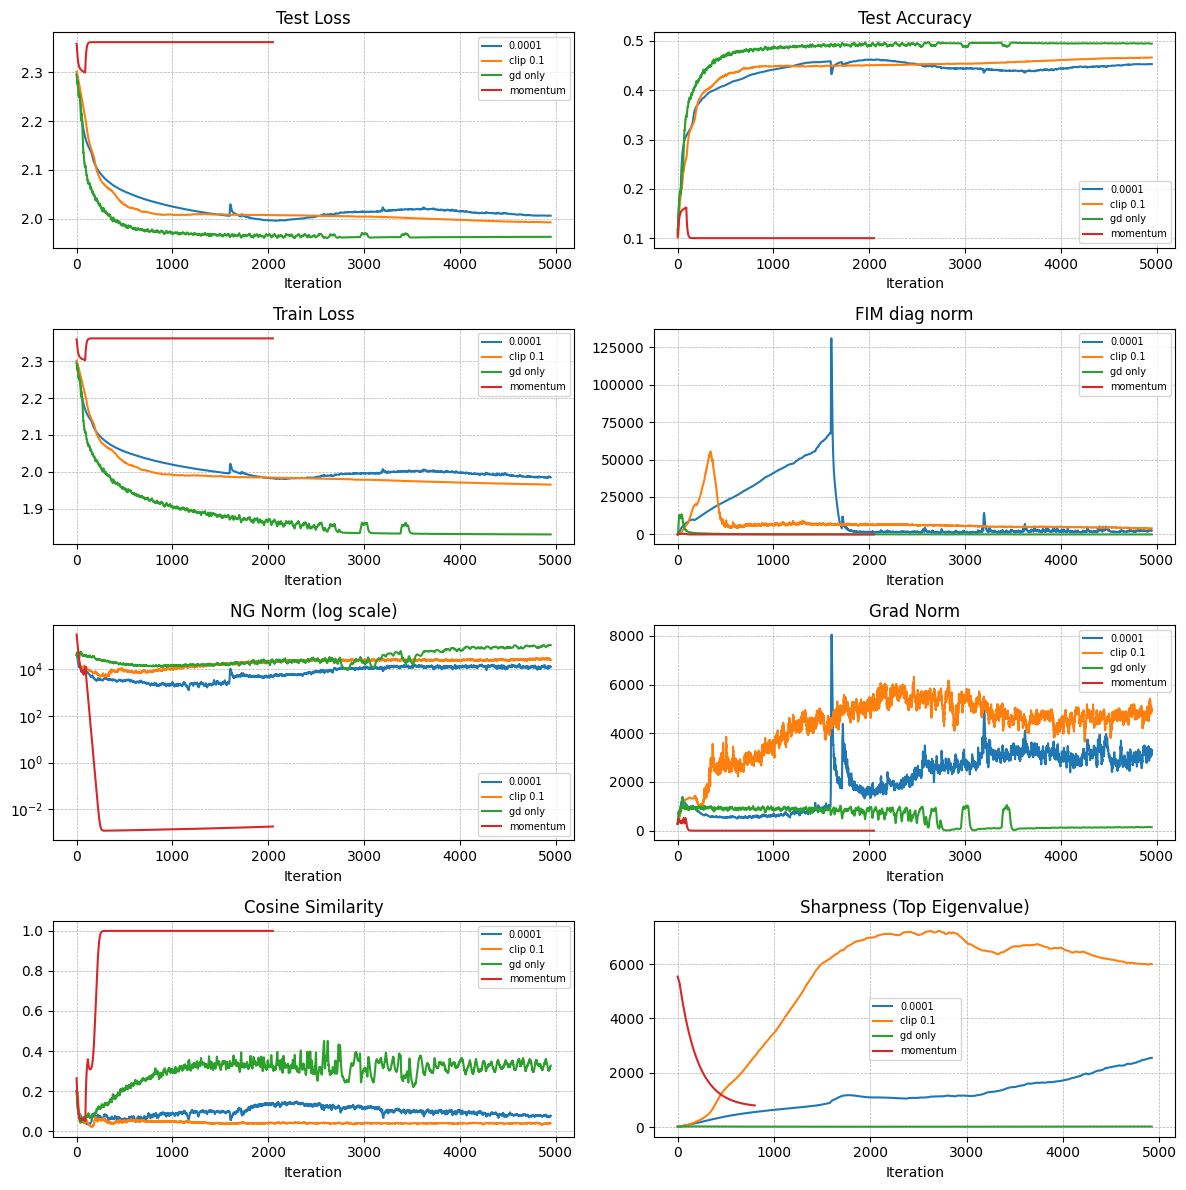

In [7]:
dataset = "cifar10"
arch_id = "cnn-relu"
loss = "ce"

plot_multiple_experiments([
    (make_directory(dataset, arch_id, loss, NGD.EmpiricalNGD.Params(
        lr = 0.00001,
        fisher_batch_size=50000,
        physical_batch_size=5000,
        epsilon=1e-5,
        ), seed=0), 
        "0.0001", 20, None),
    (make_directory(dataset, arch_id, loss, NGD.EmpiricalNGD.Params(
        lr = 1.0,
        fisher_batch_size=50000,
        physical_batch_size=5000,
        epsilon=1e-5,
        clip=0.1,
        ), seed=0), 
        "clip 0.1", 20, None),
    (make_directory(dataset, arch_id, loss, NGD.EmpiricalNGD.Params(
        lr = 0.0005,
        fisher_batch_size=50000,
        physical_batch_size=5000,
        epsilon=1e-5,
        gd_only=True,
        ), seed=0), 
        "gd only", 20, None),
    (make_directory(dataset, arch_id, loss, NGD.EmpiricalNGD.Params(
        lr = 0.0001,
        fisher_batch_size=50000,
        physical_batch_size=5000,
        epsilon=1e-5,
        momentum=0.9,
        ), seed=0), 
        "momentum", 20, None),
    ])

pseudo conditional 

histogram:
ox: norma FIM
wypełnienie kolorem jaki % accuracy

czemu norma FIM zależna od batch size?

Plotting 7 experiments
Loading from /home/ts/tcs/pr/eos/edge-of-stability/results/cifar10/cnn-relu/ce/seed_0/ngd/lr_0.0001__fisher_bs_128__phys_bs_64__epsilon_1e-05__gradient_bs_512


Loading from /home/ts/tcs/pr/eos/edge-of-stability/results/cifar10/cnn-relu/ce/seed_0/ngd/lr_0.0001__fisher_bs_256__phys_bs_64__epsilon_1e-05__gradient_bs_512
Loading from /home/ts/tcs/pr/eos/edge-of-stability/results/cifar10/cnn-relu/ce/seed_0/ngd/lr_0.0001__fisher_bs_512__phys_bs_512__epsilon_1e-05__gradient_bs_512
Loading from /home/ts/tcs/pr/eos/edge-of-stability/results/cifar10/cnn-relu/ce/seed_0/ngd/lr_0.0001__fisher_bs_1024__phys_bs_512__epsilon_1e-05__gradient_bs_512
Loading from /home/ts/tcs/pr/eos/edge-of-stability/results/cifar10/cnn-relu/ce/seed_0/ngd/lr_0.0001__fisher_bs_2048__phys_bs_512__epsilon_1e-05__gradient_bs_512
Loading from /home/ts/tcs/pr/eos/edge-of-stability/results/cifar10/cnn-relu/ce/seed_0/ngd/lr_0.0001__fisher_bs_4096__phys_bs_512__epsilon_1e-05__gradient_bs_512
Loading from /home/ts/tcs/pr/eos/edge-of-stability/results/cifar10/cnn-relu/ce/seed_0/ngd/lr_0.0001__fisher_bs_10000__phys_bs_512__epsilon_1e-05__gradient_bs_512


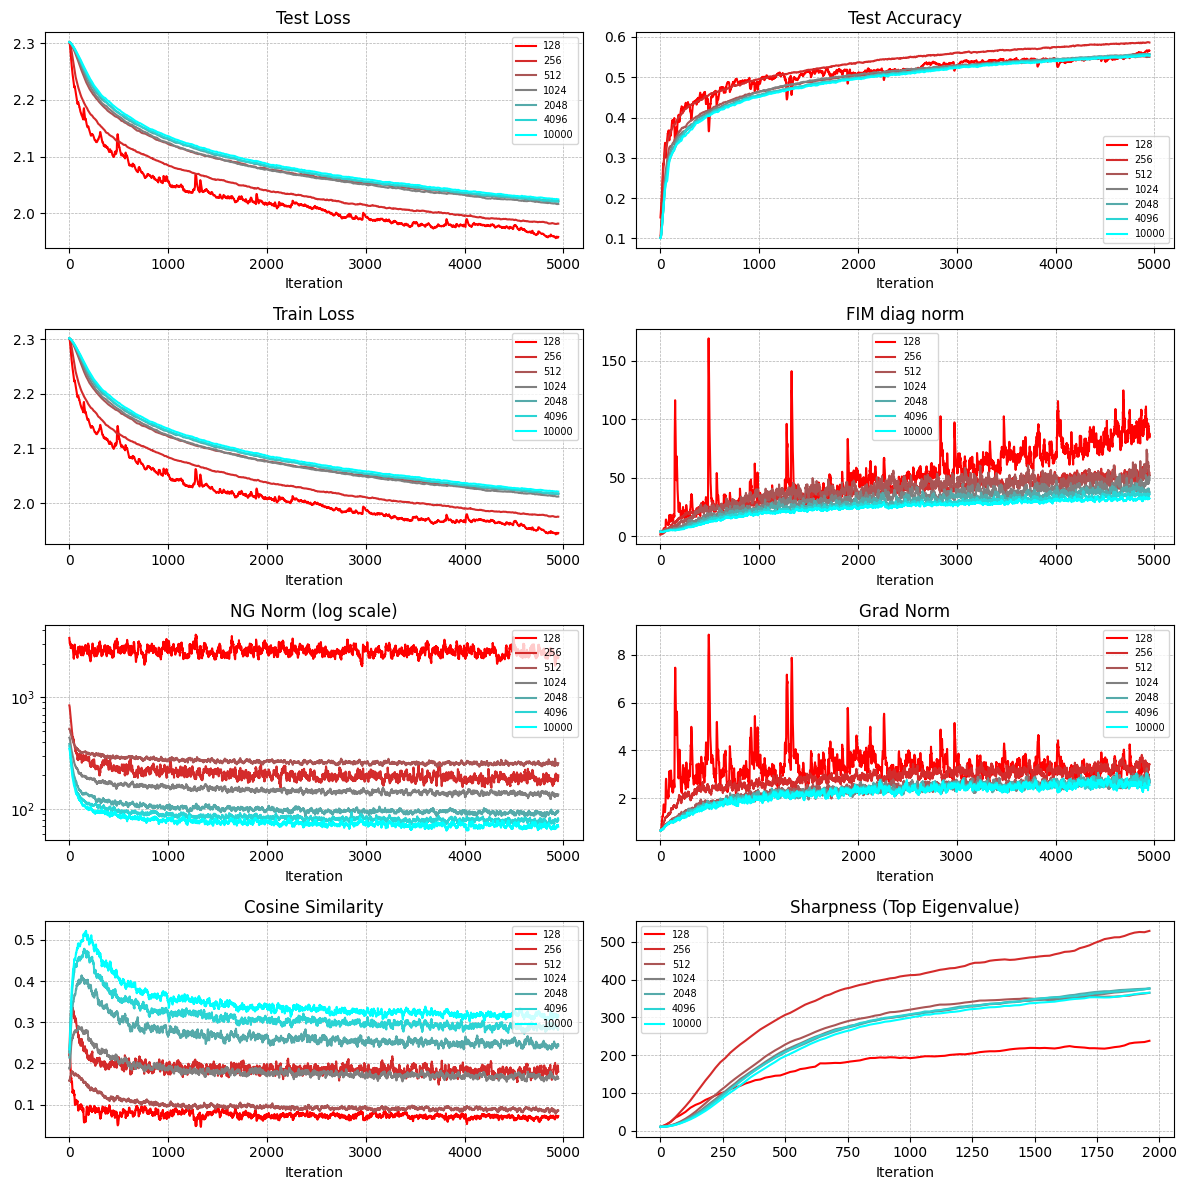

In [8]:
dataset = "cifar10"
arch_id = "cnn-relu"
loss = "ce"

plot_multiple_experiments([
    
    # (make_directory(dataset, arch_id, loss, NGD.EmpiricalNGD.Params(
    #     lr = 0.0001,
    #     fisher_batch_size=64,
    #     physical_batch_size=64,
    #     gradient_batch_size=512,
    #     epsilon=1e-5,
    #     ), seed=0), 
    #     "64", 20),
    (make_directory(dataset, arch_id, loss, NGD.EmpiricalNGD.Params(
        lr = 0.0001,
        fisher_batch_size=128,
        physical_batch_size=64,
        gradient_batch_size=512,
        epsilon=1e-5,
        ), seed=0), 
        "128", 20, 0),
    (make_directory(dataset, arch_id, loss, NGD.EmpiricalNGD.Params(
        lr = 0.0001,
        fisher_batch_size=256,
        physical_batch_size=64,
        gradient_batch_size=512,
        epsilon=1e-5,
        ), seed=0), 
        "256", 20, 1),
    (make_directory(dataset, arch_id, loss, NGD.EmpiricalNGD.Params(
        lr = 0.0001,
        fisher_batch_size=512,
        physical_batch_size=512,
        gradient_batch_size=512,
        epsilon=1e-5,
        ), seed=0), 
        "512", 20, 2),
    (make_directory(dataset, arch_id, loss, NGD.EmpiricalNGD.Params(
        lr = 0.0001,
        fisher_batch_size=1024,
        physical_batch_size=512,
        gradient_batch_size=512,
        epsilon=1e-5,
        ), seed=0), 
        "1024", 20, 3),
    (make_directory(dataset, arch_id, loss, NGD.EmpiricalNGD.Params(
        lr = 0.0001,
        fisher_batch_size=2048,
        physical_batch_size=512,
        gradient_batch_size=512,
        epsilon=1e-5,
        ), seed=0), 
        "2048", 20, 4),
    (make_directory(dataset, arch_id, loss, NGD.EmpiricalNGD.Params(
        lr = 0.0001,
        fisher_batch_size=4096,
        physical_batch_size=512,
        gradient_batch_size=512,
        epsilon=1e-5,
        ), seed=0), 
        "4096", 20, 5),
    (make_directory(dataset, arch_id, loss, NGD.EmpiricalNGD.Params(
        lr = 0.0001,
        fisher_batch_size=10000,
        physical_batch_size=512,
        gradient_batch_size=512,
        epsilon=1e-5,
        ), seed=0), 
        "10000", 20, 6),
    ])

Plotting 5 experiments
Loading from /home/ts/tcs/pr/eos/edge-of-stability/results/cifar10/cnn-relu/ce/seed_0/ngd/lr_0.0001__fisher_bs_100__phys_bs_128__epsilon_1e-05__gradient_bs_128


Loading from /home/ts/tcs/pr/eos/edge-of-stability/results/cifar10/cnn-relu/ce/seed_0/ngd/lr_0.0001__fisher_bs_1000__phys_bs_128__epsilon_1e-05__gradient_bs_128
Loading from /home/ts/tcs/pr/eos/edge-of-stability/results/cifar10/cnn-relu/ce/seed_0/ngd/lr_0.0001__fisher_bs_500__phys_bs_128__epsilon_1e-05__gradient_bs_128
Loading from /home/ts/tcs/pr/eos/edge-of-stability/results/cifar10/cnn-relu/ce/seed_0/ngd/lr_0.0001__fisher_bs_50__phys_bs_128__epsilon_1e-05__gradient_bs_128
Loading from /home/ts/tcs/pr/eos/edge-of-stability/results/cifar10/cnn-relu/ce/seed_0/ngd/lr_0.0001__fisher_bs_100__phys_bs_128__epsilon_1e-05__gradient_bs_128


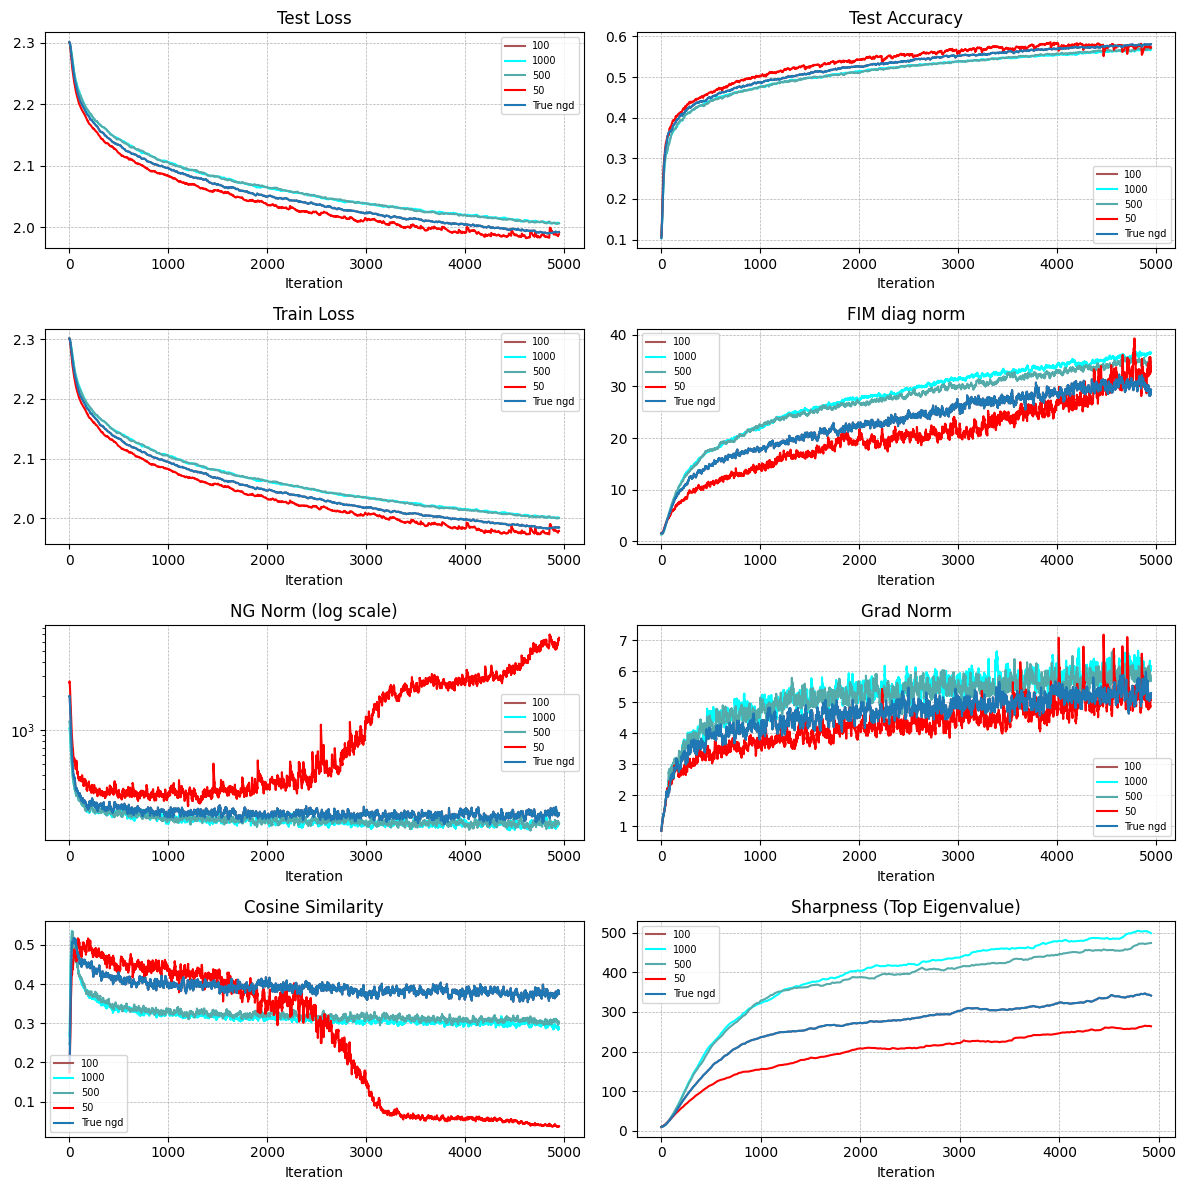

In [9]:
dataset = "cifar10"
arch_id = "cnn-relu"
loss = "ce"

plot_multiple_experiments([
    (make_directory(dataset, arch_id, loss, NGD.EmpiricalNGD.Params(
        lr = 0.0001,
        fisher_batch_size=100,
        physical_batch_size=128,
        gradient_batch_size=128,
        epsilon=1e-5,
        ), seed=0), 
        "100", 20, 0),
    (make_directory(dataset, arch_id, loss, NGD.EmpiricalNGD.Params(
        lr = 0.0001,
        fisher_batch_size=1000,
        physical_batch_size=128,
        gradient_batch_size=128,
        epsilon=1e-5,
        ), seed=0), 
        "1000", 20, 2),
    (make_directory(dataset, arch_id, loss, NGD.EmpiricalNGD.Params(
        lr = 0.0001,
        fisher_batch_size=500,
        physical_batch_size=128,
        gradient_batch_size=128,
        epsilon=1e-5,
        ), seed=0), 
        "500", 20, 1),
    (make_directory(dataset, arch_id, loss, NGD.EmpiricalNGD.Params(
        lr = 0.0001,
        fisher_batch_size=50,
        physical_batch_size=128,
        gradient_batch_size=128,
        epsilon=1e-5,
        ), seed=0), 
        "50", 20, -1),
    (make_directory(dataset, arch_id, loss, NGD.TrueNGD.Params(
        lr = 0.0001,
        fisher_batch_size=100,
        physical_batch_size=128,
        gradient_batch_size=128,
        epsilon=1e-5,
        ), seed=0), 
        "True ngd", 20, None),
    ])

Plotting 2 experiments
Loading from /home/ts/tcs/pr/eos/edge-of-stability/results/cifar10/cnn-relu/ce/seed_0/ngd/lr_0.0001__fisher_bs_100__phys_bs_128__epsilon_1e-05__gradient_bs_128
Loading from /home/ts/tcs/pr/eos/edge-of-stability/results/cifar10/cnn-relu/ce/seed_0/ngd/lr_0.0001__fisher_bs_1000__phys_bs_128__epsilon_1e-05__gradient_bs_128


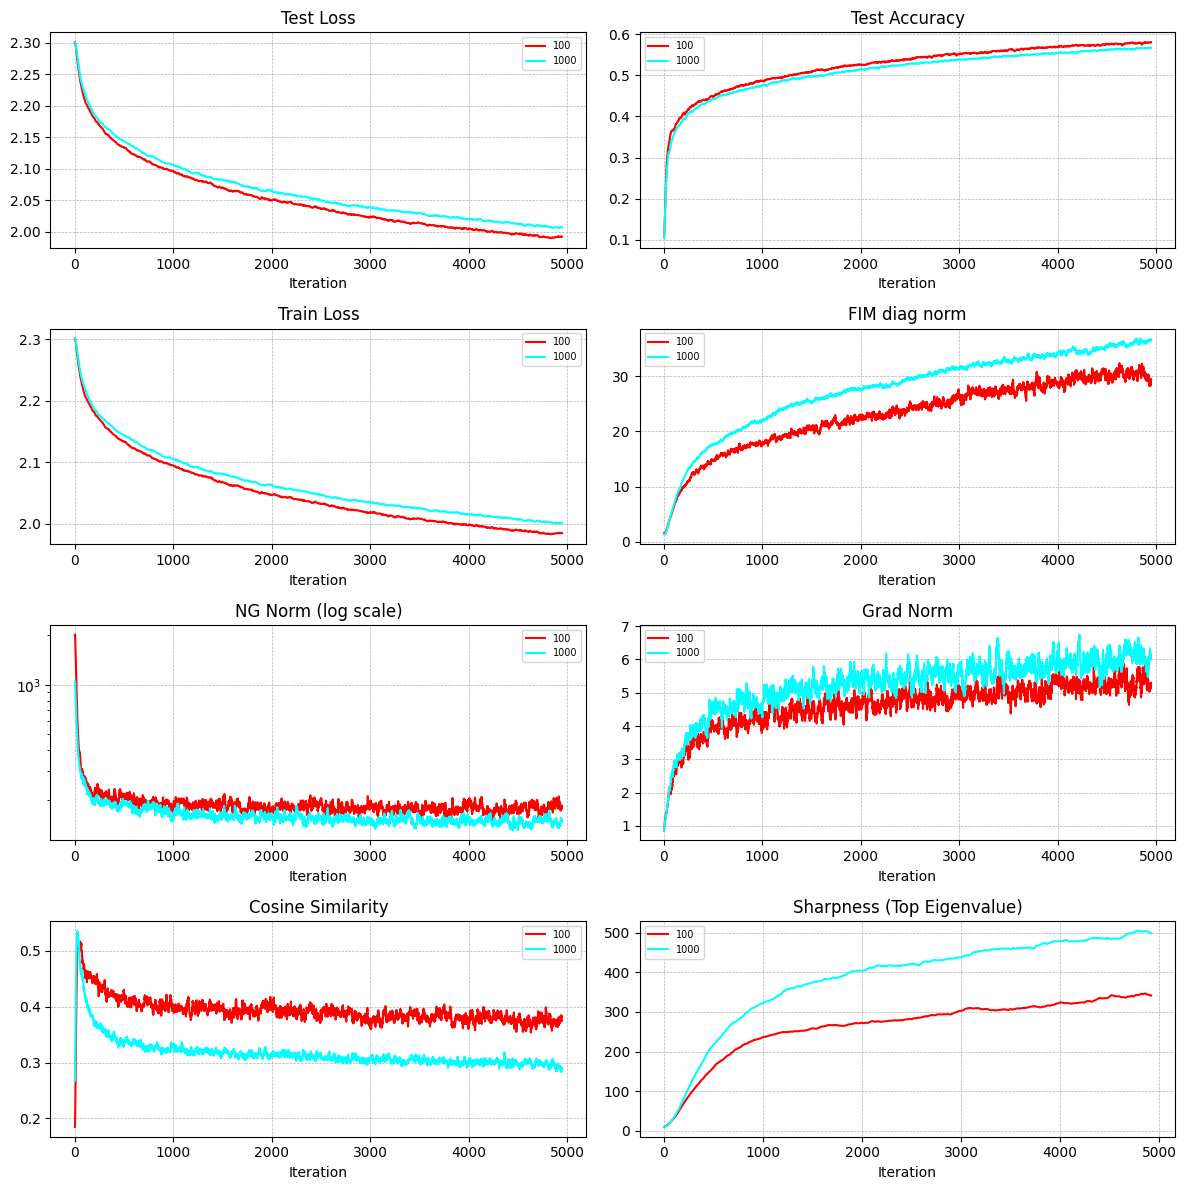

In [10]:
plot_multiple_experiments([
    (make_directory(dataset, arch_id, loss, NGD.TrueNGD.Params(
        lr = 0.0001,
        fisher_batch_size=100,
        physical_batch_size=128,
        gradient_batch_size=128,
        epsilon=1e-5,
        ), seed=0, ngd_type="ngd"), 
        "100", 20, 0),
    (make_directory(dataset, arch_id, loss, NGD.TrueNGD.Params(
        lr = 0.0001,
        fisher_batch_size=1000,
        physical_batch_size=128,
        gradient_batch_size=128,
        epsilon=1e-5,
        ), seed=0, ngd_type="ngd"), 
        "1000", 20, 2),
])

Plotting 2 experiments
Loading from /home/ts/tcs/pr/eos/edge-of-stability/results/cifar10-5k/cnn-relu/ce/seed_23/ngd/lr_0.001__fisher_bs_5000__phys_bs_1000__epsilon_1e-06__gradient_bs_1000
Loading from /home/ts/tcs/pr/eos/edge-of-stability/results/cifar10-5k/cnn-relu/ce/seed_23/ngd/lr_0.002__fisher_bs_5000__phys_bs_1000__epsilon_1e-06__gradient_bs_1000


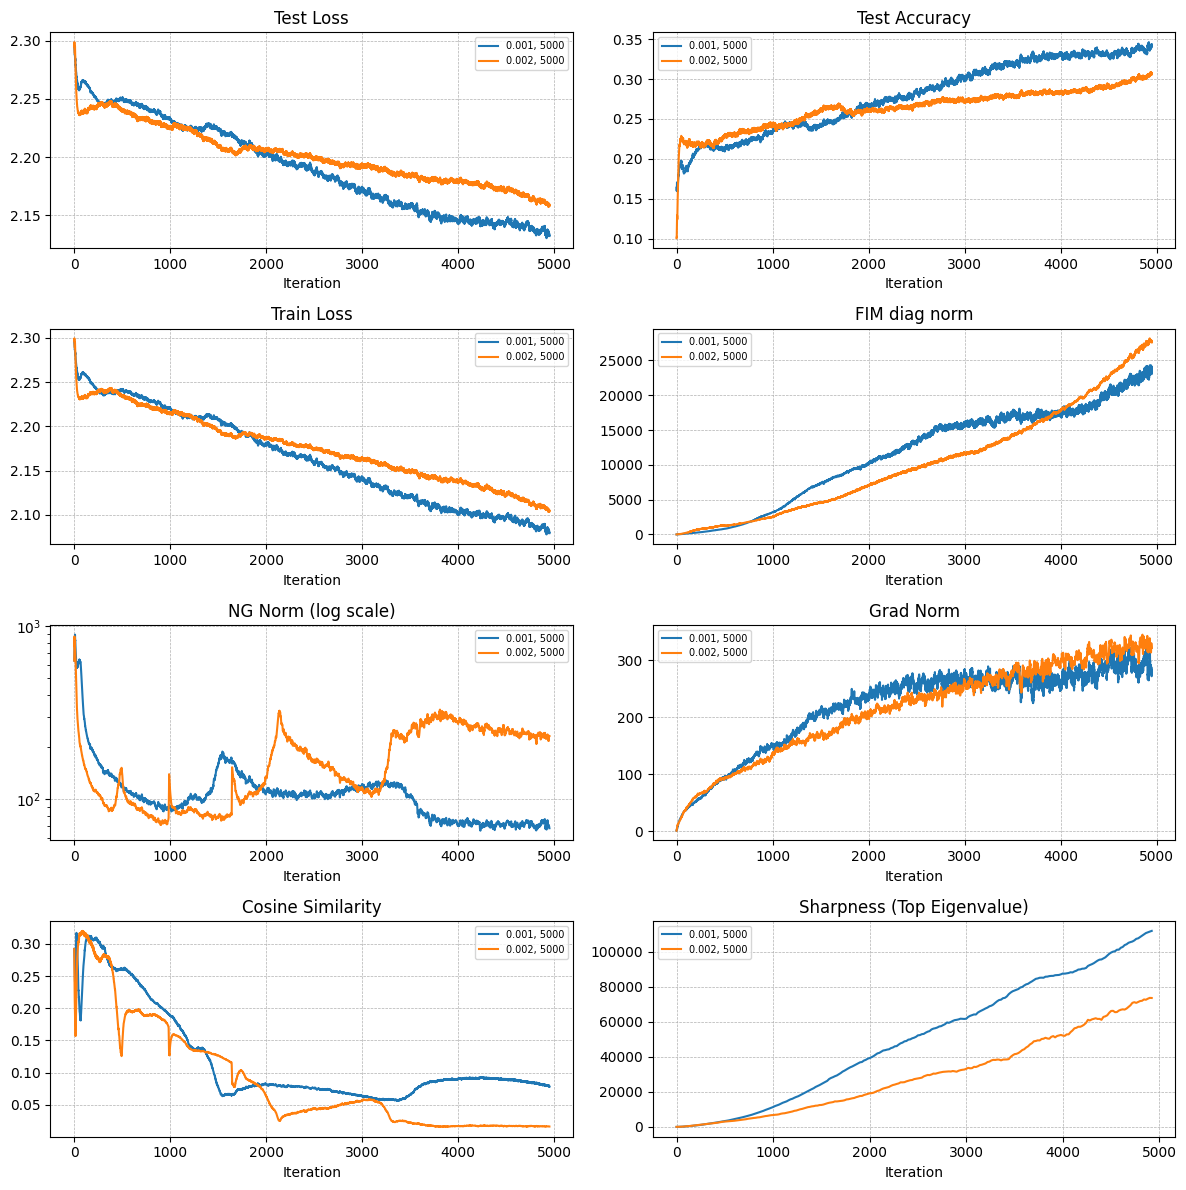

In [11]:
dataset = "cifar10-5k"
arch_id = "cnn-relu"
loss = "ce"

plot_multiple_experiments([
    # (make_directory(dataset, arch_id, loss, NGD.EmpiricalNGD.Params(
    #     lr = 0.001,
    #     fisher_batch_size=1000,
    #     physical_batch_size=1000,
    #     gradient_batch_size=1000,
    #     epsilon=1e-6,
    #     ), seed=23), 
    #     "0.001, 1000", 20, None),
    # # (make_directory(dataset, arch_id, loss, NGD.EmpiricalNGD.Params(
    #     lr = 0.002,
    #     fisher_batch_size=1000,
    #     physical_batch_size=1000,
    #     gradient_batch_size=1000,
    #     epsilon=1e-6,
    #     ), seed=23), 
    #     "0.002, 1000", 20, None),
    (make_directory(dataset, arch_id, loss, NGD.EmpiricalNGD.Params(
        lr = 0.001,
        fisher_batch_size=5000,
        physical_batch_size=1000,
        gradient_batch_size=1000,
        epsilon=1e-6,
        ), seed=23), 
        "0.001, 5000", 20, None),
    (make_directory(dataset, arch_id, loss, NGD.EmpiricalNGD.Params(
        lr = 0.002,
        fisher_batch_size=5000,
        physical_batch_size=1000,
        gradient_batch_size=1000,
        epsilon=1e-6,
        ), seed=23),
        "0.002, 5000", 20, None),
    ])

Plotting 4 experiments
Loading from /home/ts/tcs/pr/eos/edge-of-stability/results/cifar10-5k/cnn-relu/ce/seed_23/ngd/lr_0.001__fisher_bs_1000__phys_bs_1000__epsilon_1e-06__gradient_bs_1000
Loading from /home/ts/tcs/pr/eos/edge-of-stability/results/cifar10-5k/cnn-relu/ce/seed_23/ngd/lr_0.002__fisher_bs_1000__phys_bs_1000__epsilon_1e-06__gradient_bs_1000
Loading from /home/ts/tcs/pr/eos/edge-of-stability/results/cifar10-5k/cnn-relu/ce/seed_23/ngd/lr_0.001__fisher_bs_5000__phys_bs_1000__epsilon_1e-06__gradient_bs_1000
Loading from /home/ts/tcs/pr/eos/edge-of-stability/results/cifar10-5k/cnn-relu/ce/seed_23/ngd/lr_0.002__fisher_bs_5000__phys_bs_1000__epsilon_1e-06__gradient_bs_1000


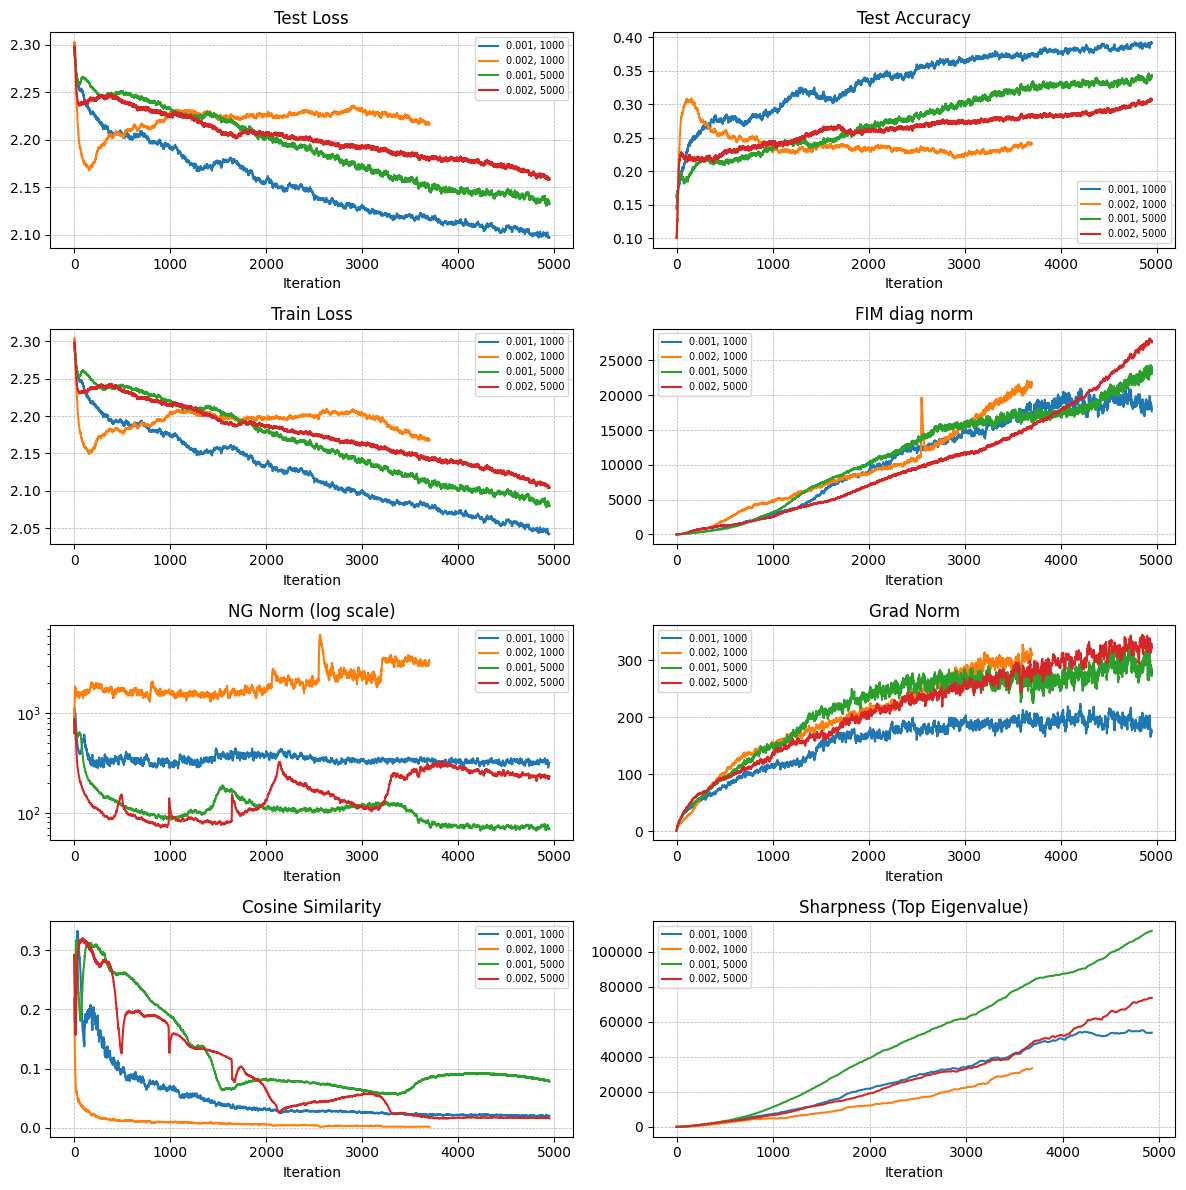

In [12]:
dataset = "cifar10-5k"
arch_id = "cnn-relu"
loss = "ce"

plot_multiple_experiments([
    (make_directory(dataset, arch_id, loss, NGD.EmpiricalNGD.Params(
        lr = 0.001,
        fisher_batch_size=1000,
        physical_batch_size=1000,
        gradient_batch_size=1000,
        epsilon=1e-6,
        ), seed=23), 
        "0.001, 1000", 20, None),
    (make_directory(dataset, arch_id, loss, NGD.EmpiricalNGD.Params(
        lr = 0.002,
        fisher_batch_size=1000,
        physical_batch_size=1000,
        gradient_batch_size=1000,
        epsilon=1e-6,
        ), seed=23), 
        "0.002, 1000", 20, None),
    (make_directory(dataset, arch_id, loss, NGD.EmpiricalNGD.Params(
        lr = 0.001,
        fisher_batch_size=5000,
        physical_batch_size=1000,
        gradient_batch_size=1000,
        epsilon=1e-6,
        ), seed=23), 
        "0.001, 5000", 20, None),
    (make_directory(dataset, arch_id, loss, NGD.EmpiricalNGD.Params(
        lr = 0.002,
        fisher_batch_size=5000,
        physical_batch_size=1000,
        gradient_batch_size=1000,
        epsilon=1e-6,
        ), seed=23),
        "0.002, 5000", 20, None),
    ])

Plotting 3 experiments
Loading from /home/ts/tcs/pr/eos/edge-of-stability/results/cifar10-5k/cnn-relu/ce/seed_2406/ngd/lr_0.0005__fisher_bs_100__phys_bs_1000__epsilon_1e-06__gradient_bs_1000__grad_amount_0.5


Loading from /home/ts/tcs/pr/eos/edge-of-stability/results/cifar10-5k/cnn-relu/ce/seed_2406/ngd/lr_0.0005__fisher_bs_100__phys_bs_1000__epsilon_1e-06__gradient_bs_1000__grad_amount_0.2
Loading from /home/ts/tcs/pr/eos/edge-of-stability/results/cifar10-5k/cnn-relu/ce/seed_2406/ngd/lr_0.0005__fisher_bs_100__phys_bs_1000__epsilon_1e-06__gradient_bs_1000__grad_amount_0.1


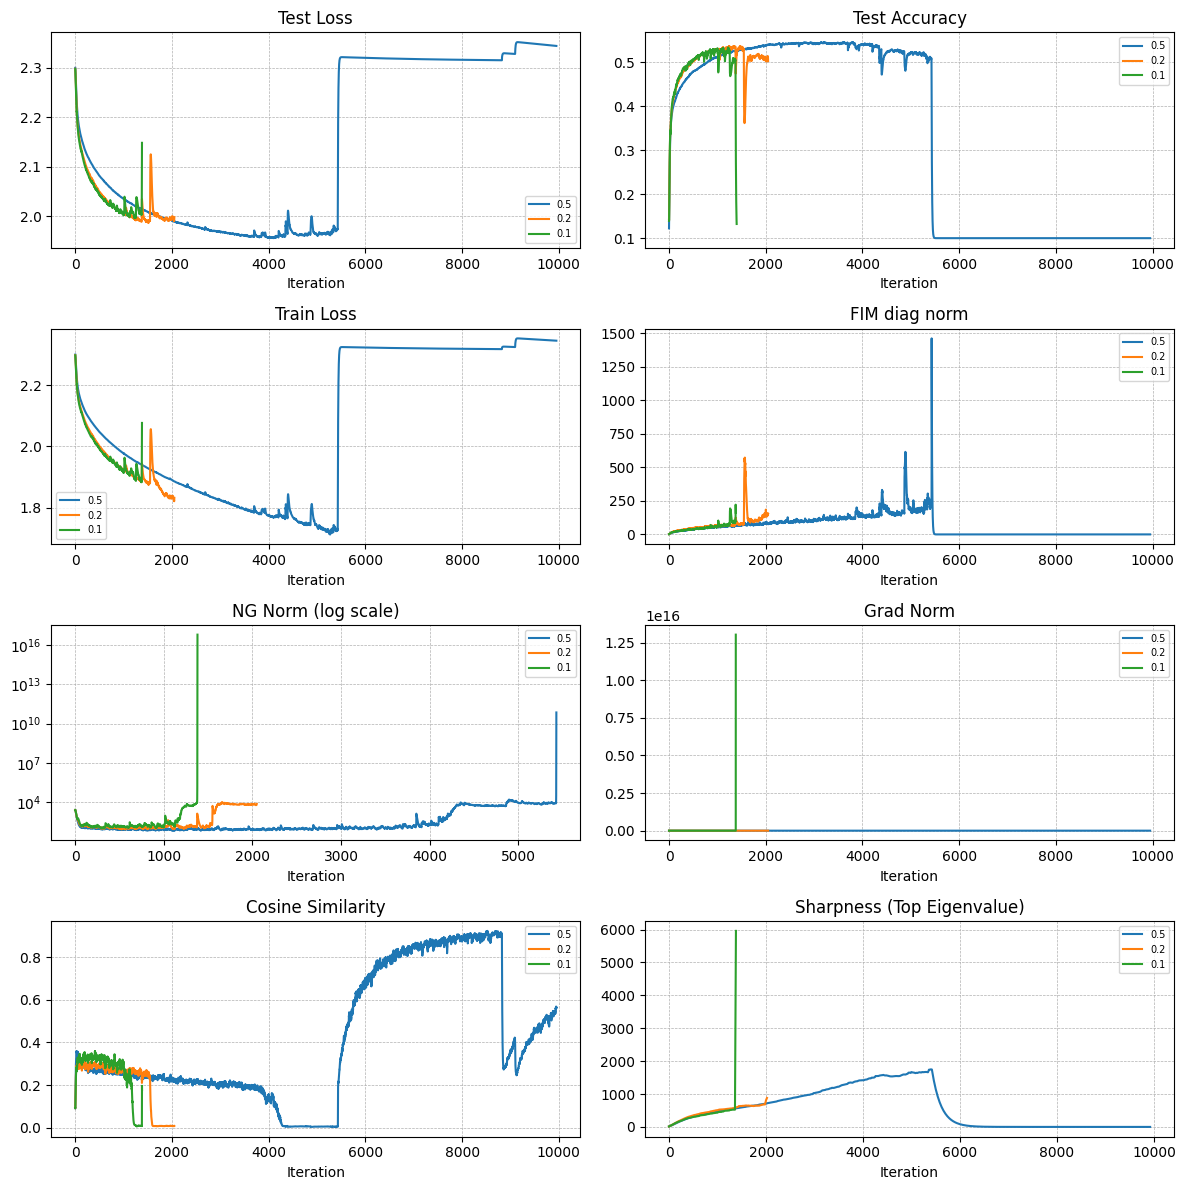

In [13]:
dataset = "cifar10-5k"
arch_id = "cnn-relu"
loss = "ce"

plot_multiple_experiments([
    (make_directory(dataset, arch_id, loss, NGD.EmpiricalNGD.Params(
        lr = 0.0005,
        fisher_batch_size=100,
        physical_batch_size=1000,
        gradient_batch_size=1000,
        epsilon=1e-6,
        grad_amount=.5,
        ), seed=2406), 
        "0.5", 20, None),
    (make_directory(dataset, arch_id, loss, NGD.EmpiricalNGD.Params(
        lr = 0.0005,
        fisher_batch_size=100,
        physical_batch_size=1000,
        gradient_batch_size=1000,
        epsilon=1e-6,
        grad_amount=0.2,
        ), seed=2406), 
        "0.2", 20, None),
    (make_directory(dataset, arch_id, loss, NGD.EmpiricalNGD.Params(
        lr = 0.0005,
        fisher_batch_size=100,
        physical_batch_size=1000,
        gradient_batch_size=1000,
        epsilon=1e-6,
        grad_amount=0.1,
        ), seed=2406), 
        "0.1", 20, None),
    ])